### Importación de datos



In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda1["Tienda"] = "Tienda 1"
tienda2["Tienda"] = "Tienda 2"
tienda3["Tienda"] = "Tienda 3"
tienda4["Tienda"] = "Tienda 4"


df = pd.concat([tienda1, tienda2, tienda3, tienda4], ignore_index=True)
df.head()

#verificador de columnas
print(df.columns.tolist())
print(f"\nTotal de registros: {len(df):,}")
df.head()

['Producto', 'Categoría del Producto', 'Precio', 'Costo de envío', 'Fecha de Compra', 'Vendedor', 'Lugar de Compra', 'Calificación', 'Método de pago', 'Cantidad de cuotas', 'lat', 'lon', 'Tienda']

Total de registros: 9,435


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Tienda
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175,Tienda 1
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359,Tienda 1
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444,Tienda 1
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250,Tienda 1
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359,Tienda 1


#1. Análisis de facturación



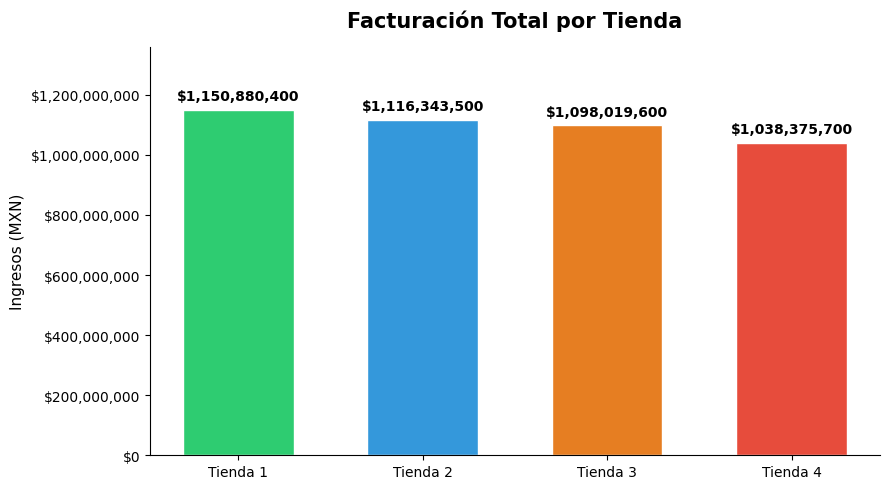

In [25]:
facturacion = df.groupby("Tienda")["Precio"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colores = ["#2ecc71", "#3498db", "#e67e22", "#e74c3c"]
bars = ax.bar(facturacion.index, facturacion.values, color=colores, edgecolor="white", width=0.6)

ax.set_title("Facturación Total por Tienda", fontsize=15, fontweight="bold", pad=15)
ax.set_ylabel("Ingresos (MXN)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_ylim(0, facturacion.max() * 1.18)

for bar, val in zip(bars, facturacion.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + facturacion.max() * 0.02,
            f"${val:,.0f}", ha="center", va="bottom", fontweight="bold", fontsize=10)

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [26]:
print("\nFacturación Total:")
for t, v in facturacion.items():
    print(f"  {t}: ${v:,.2f}")


Facturación Total:
  Tienda 1: $1,150,880,400.00
  Tienda 2: $1,116,343,500.00
  Tienda 3: $1,098,019,600.00
  Tienda 4: $1,038,375,700.00


# 2. Ventas por categoría

In [24]:
print(df.columns.tolist())

['Producto', 'Categoría del Producto', 'Precio', 'Costo de envío', 'Fecha de Compra', 'Vendedor', 'Lugar de Compra', 'Calificación', 'Método de pago', 'Cantidad de cuotas', 'lat', 'lon', 'Tienda']


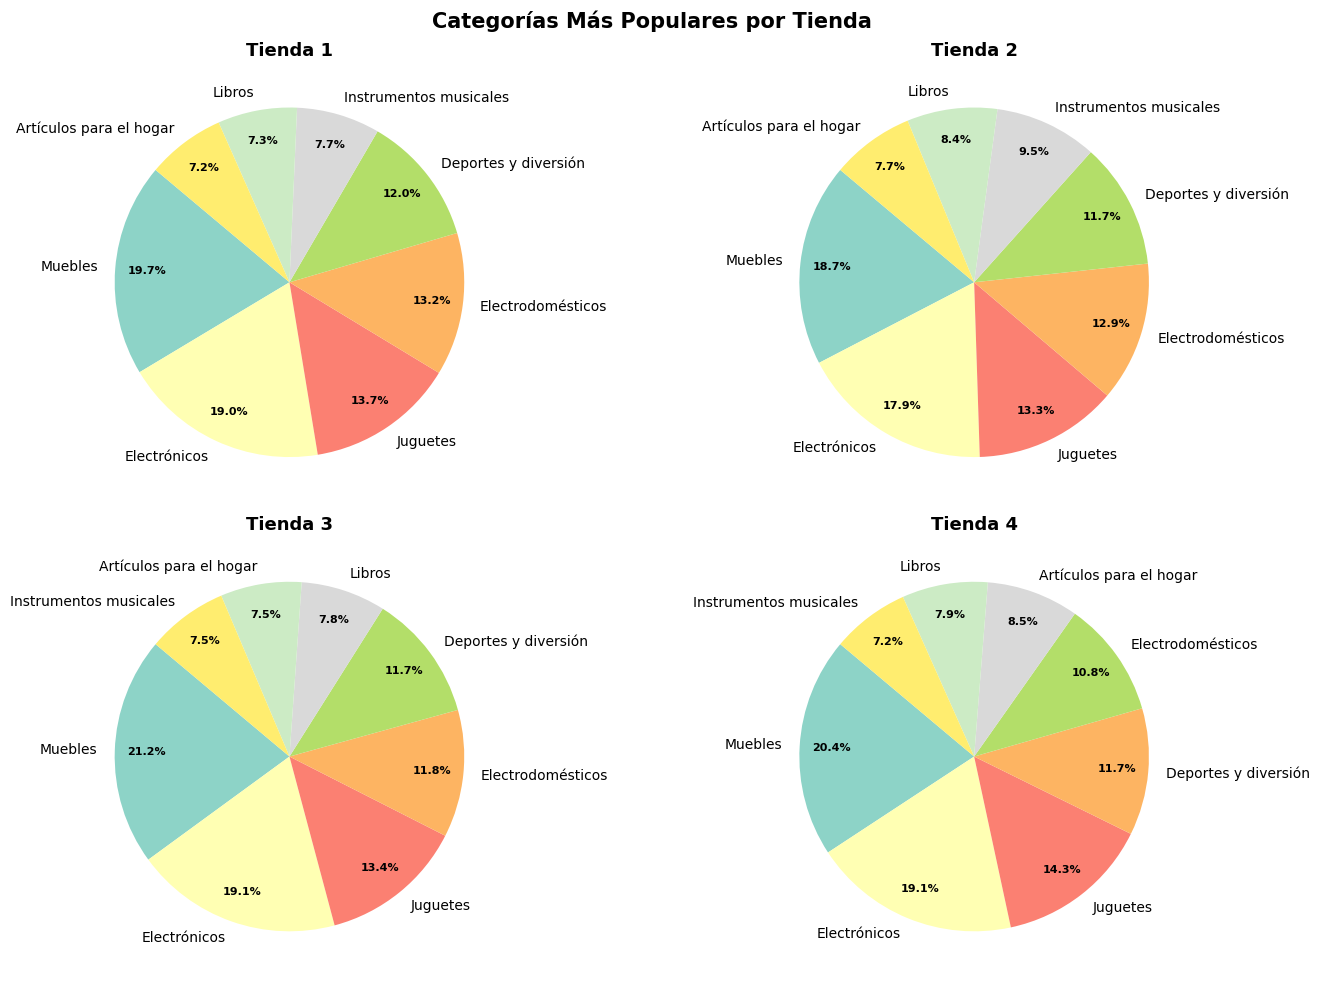

In [28]:
categorias = df.groupby(["Tienda", "Categoría del Producto"])["Precio"].count().reset_index()
categorias.columns = ["Tienda", "Categoría", "Ventas"]

tiendas = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Categorías Más Populares por Tienda", fontsize=15, fontweight="bold")

for ax, tienda in zip(axes.flatten(), tiendas):
    datos = categorias[categorias["Tienda"] == tienda].sort_values("Ventas", ascending=False)
    colores_cat = plt.cm.Set3(np.linspace(0, 1, len(datos)))
    wedges, texts, autotexts = ax.pie(
        datos["Ventas"], labels=datos["Categoría"], autopct="%1.1f%%",
        colors=colores_cat, startangle=140, pctdistance=0.82
    )
    for t in autotexts:
        t.set_fontsize(8)
        t.set_fontweight("bold")
    ax.set_title(tienda, fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

# 3. Calificación promedio de la tienda


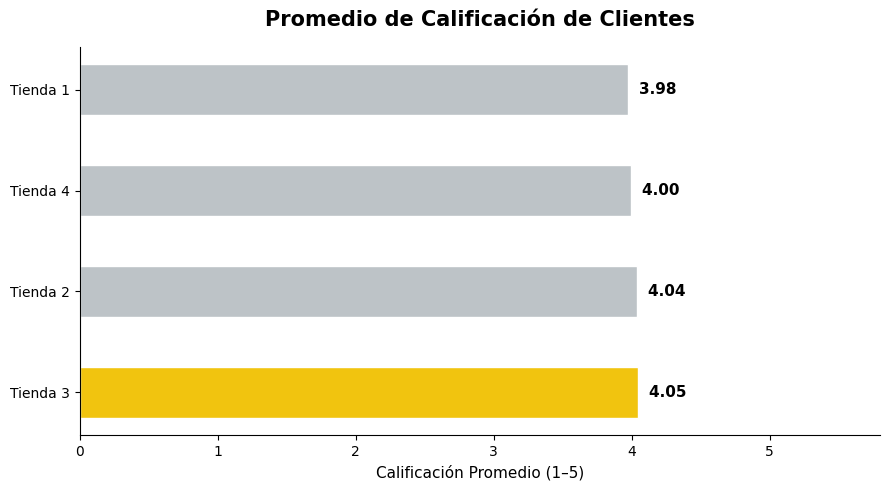


Calificación Promedio:
  Tienda 3: 4.05
  Tienda 2: 4.04
  Tienda 4: 4.00
  Tienda 1: 3.98


In [32]:
calificacion = df.groupby("Tienda")["Calificación"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colores_cal = ["#f1c40f" if v == calificacion.max() else "#bdc3c7" for v in calificacion.values]
bars = ax.barh(calificacion.index, calificacion.values, color=colores_cal, edgecolor="white", height=0.5)

ax.set_title("Promedio de Calificación de Clientes", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Calificación Promedio (1–5)", fontsize=11)
ax.set_xlim(0, 5.8)

for bar, val in zip(bars, calificacion.values):
    ax.text(val + 0.08, bar.get_y() + bar.get_height()/2,
            f"{val:.2f} ", va="center", fontweight="bold", fontsize=11)

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("\nCalificación Promedio:")
for t, v in calificacion.items():
    print(f"  {t}: {v:.2f}")

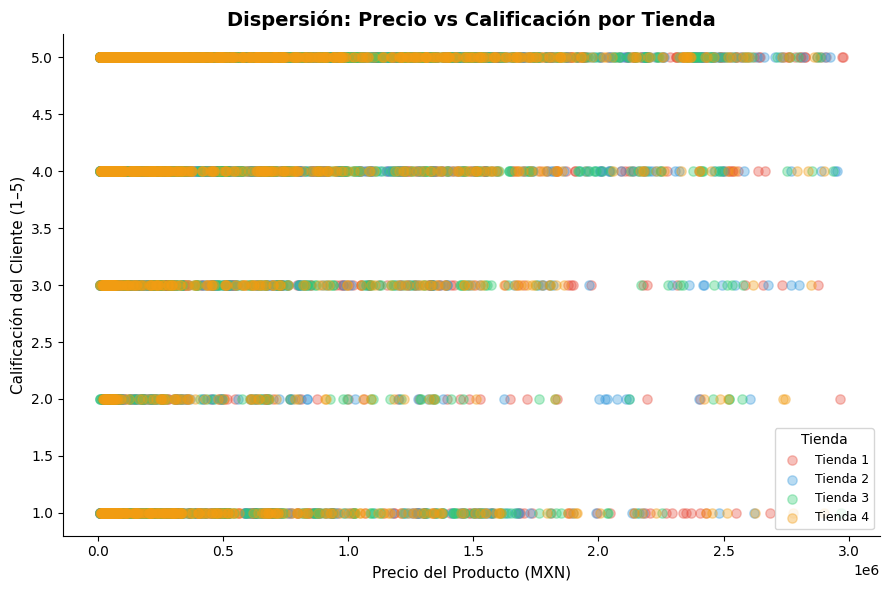

In [36]:
colores_tienda = {"Tienda 1": "#e74c3c", "Tienda 2": "#3498db",
                  "Tienda 3": "#2ecc71",  "Tienda 4": "#f39c12"}

fig, ax = plt.subplots(figsize=(9, 6))

for tienda, grupo in df.groupby("Tienda"):
    ax.scatter(grupo["Precio"], grupo["Calificación"],
               alpha=0.35, s=45, label=tienda,
               color=colores_tienda[tienda])

ax.set_title("Dispersión: Precio vs Calificación por Tienda", fontsize=14, fontweight="bold")
ax.set_xlabel("Precio del Producto (MXN)", fontsize=11)
ax.set_ylabel("Calificación del Cliente (1–5)", fontsize=11)
ax.legend(title="Tienda", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# 4. Productos más y menos vendidos

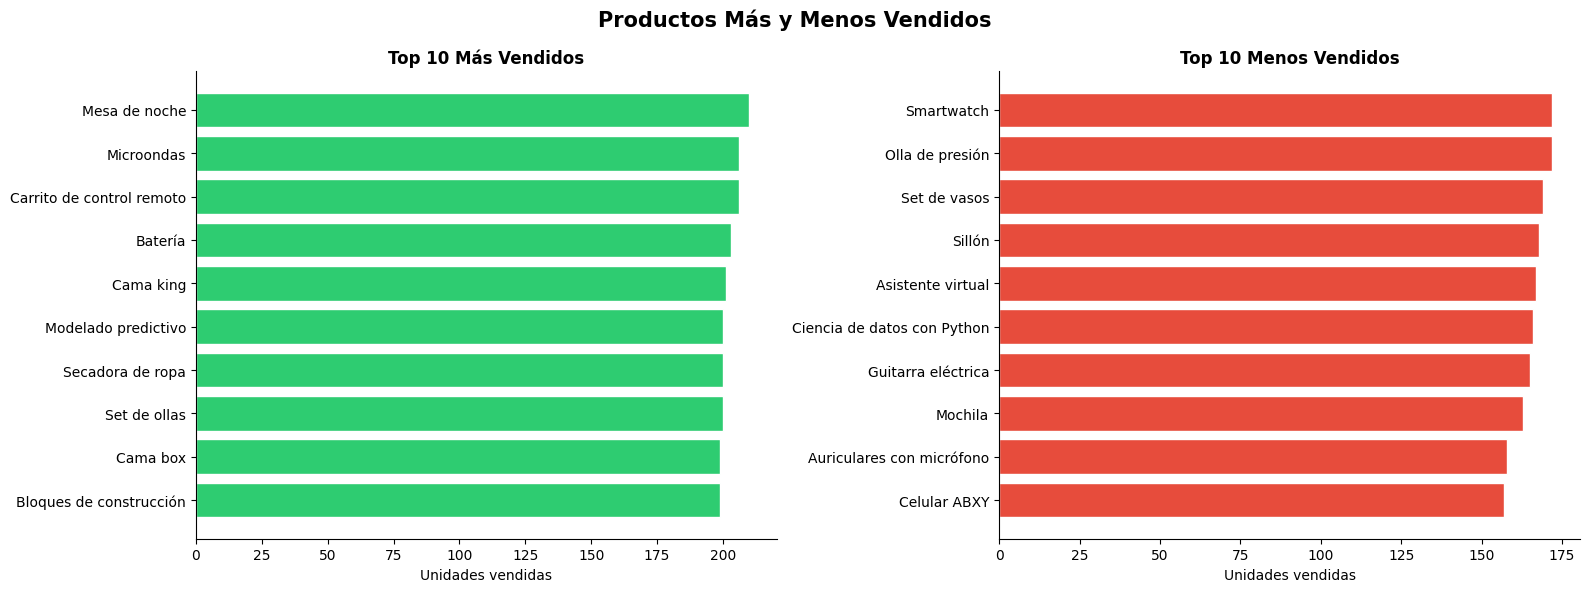

In [33]:
ventas_producto = df.groupby("Producto")["Precio"].count().sort_values(ascending=False)
top10 = ventas_producto.head(10)
bot10 = ventas_producto.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Productos Más y Menos Vendidos", fontsize=15, fontweight="bold")

axes[0].barh(top10.index[::-1], top10.values[::-1], color="#2ecc71", edgecolor="white")
axes[0].set_title("Top 10 Más Vendidos", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Unidades vendidas")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].barh(bot10.index[::-1], bot10.values[::-1], color="#e74c3c", edgecolor="white")
axes[1].set_title("Top 10 Menos Vendidos", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Unidades vendidas")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

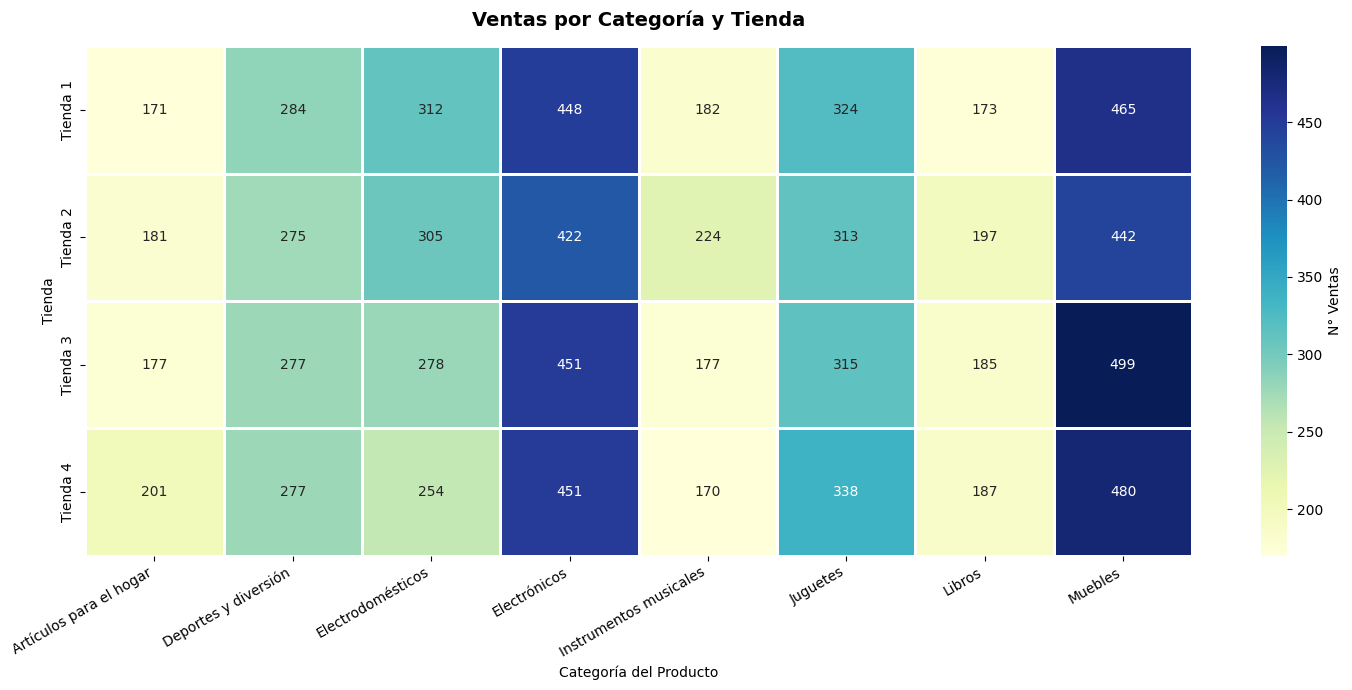

In [39]:
pivot = df.groupby(["Tienda", "Categoría del Producto"])["Precio"].count().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu",
            linewidths=0.8, ax=ax, cbar_kws={"label": "N° Ventas"})

ax.set_title("Ventas por Categoría y Tienda",
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Tienda")
ax.set_xlabel("Categoría del Producto")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda

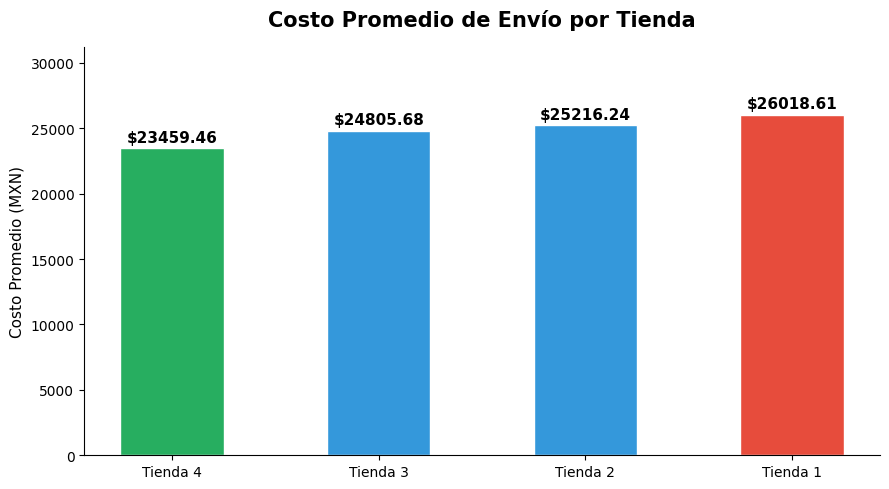


Costo Promedio de Envío:
  Tienda 4: $23459.46
  Tienda 3: $24805.68
  Tienda 2: $25216.24
  Tienda 1: $26018.61


In [34]:
envio = df.groupby("Tienda")["Costo de envío"].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colores_env = ["#27ae60" if v == envio.min() else "#e74c3c" if v == envio.max() else "#3498db" for v in envio.values]
bars = ax.bar(envio.index, envio.values, color=colores_env, edgecolor="white", width=0.5)

ax.set_title("Costo Promedio de Envío por Tienda", fontsize=15, fontweight="bold", pad=15)
ax.set_ylabel("Costo Promedio (MXN)", fontsize=11)
ax.set_ylim(0, envio.max() * 1.2)

for bar, val in zip(bars, envio.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + envio.max() * 0.02,
            f"${val:.2f}", ha="center", fontweight="bold", fontsize=11)

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("\nCosto Promedio de Envío:")
for t, v in envio.items():
    print(f"  {t}: ${v:.2f}")

# **ANÁLISIS DE RENTABILIDAD POR TIENDA**

In [41]:
resumen = pd.DataFrame({
    "Facturación ($)": df.groupby("Tienda")["Precio"].sum().round(2),
    "Calificación":    df.groupby("Tienda")["Calificación"].mean().round(2),
    "Costo Envío ($)": df.groupby("Tienda")["Costo de envío"].mean().round(2),
    "Total Ventas":    df.groupby("Tienda")["Precio"].count()
})

print("=" * 62)
print("         📊 RESUMEN COMPARATIVO DE TIENDAS")
print("=" * 62)
print(resumen.to_string())
print("=" * 62)

peor_facturacion  = resumen["Facturación ($)"].idxmin()
peor_calificacion = resumen["Calificación"].idxmin()
mayor_envio       = resumen["Costo Envío ($)"].idxmax()
menor_ventas      = resumen["Total Ventas"].idxmin()

print(f"""

Tras analizar las cuatro tiendas con base en cinco métricas
clave —facturación total, categorías más vendidas, calificación
de clientes, productos más/menos vendidos y costo de envío—
se recomienda al Sr. João VENDER {peor_facturacion}.

📌 Indicadores que respaldan la decisión:

  • Menor facturación total:      {peor_facturacion}
  • Peor calificación de clientes: {peor_calificacion}
  • Mayor costo de envío:          {mayor_envio}
  • Menor volumen de ventas:       {menor_ventas}

✅ Conclusión:
  {peor_facturacion} acumula los peores resultados en las
  métricas más relevantes del negocio. Venderla le permitiría
  al Sr. João concentrar sus recursos e inversión en las
  tiendas con mejor desempeño y mayor potencial de crecimiento.
""")

         📊 RESUMEN COMPARATIVO DE TIENDAS
          Facturación ($)  Calificación  Costo Envío ($)  Total Ventas
Tienda                                                                
Tienda 1     1.150880e+09          3.98         26018.61          2359
Tienda 2     1.116344e+09          4.04         25216.24          2359
Tienda 3     1.098020e+09          4.05         24805.68          2359
Tienda 4     1.038376e+09          4.00         23459.46          2358


Tras analizar las cuatro tiendas con base en cinco métricas
clave —facturación total, categorías más vendidas, calificación
de clientes, productos más/menos vendidos y costo de envío—
se recomienda al Sr. João VENDER Tienda 4.

📌 Indicadores que respaldan la decisión:

  • Menor facturación total:      Tienda 4
  • Peor calificación de clientes: Tienda 1
  • Mayor costo de envío:          Tienda 1
  • Menor volumen de ventas:       Tienda 4

✅ Conclusión:
  Tienda 4 acumula los peores resultados en las
  métricas más relevan